In [3]:
!pip install -q transformers datasets evaluate scikit-learn accelerate
!pip install -q tensorflow


In [4]:
from google.colab import files
uploaded = files.upload()



Saving Basics of BERT and XLM-RoBERTa - PyTorch - 2.zip to Basics of BERT and XLM-RoBERTa - PyTorch - 2 (1).zip


In [5]:
import zipfile
import os

zip_path = '/content/Basics of BERT and XLM-RoBERTa - PyTorch - 2.zip'
extract_path = '/content/dataset'
os.makedirs(extract_path, exist_ok=True)

# Décompresser le zip principal
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Contenu après 1ère extraction :", os.listdir(extract_path))


Contenu après 1ère extraction : ['Basics of BERT and XLM-RoBERTa - PyTorch']


In [6]:
import os

extract_path = '/content/dataset'
print(os.listdir(extract_path))


['Basics of BERT and XLM-RoBERTa - PyTorch']


In [7]:
import os

inner_path = '/content/dataset/Basics of BERT and XLM-RoBERTa - PyTorch'
print("Contenu du dossier :", os.listdir(inner_path))


Contenu du dossier : ['sample_submission.csv', 'train.csv.zip', 'test.csv.zip', 'test.csv', 'train.csv']


In [8]:
import zipfile
import os

# Chemins vers les zips internes
train_zip = '/content/dataset/Basics of BERT and XLM-RoBERTa - PyTorch/train.csv.zip'
test_zip = '/content/dataset/Basics of BERT and XLM-RoBERTa - PyTorch/test.csv.zip'
extract_to = '/content/dataset/Basics of BERT and XLM-RoBERTa - PyTorch'

# Extraction train.csv
with zipfile.ZipFile(train_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

# Extraction test.csv
with zipfile.ZipFile(test_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

# Vérifie les fichiers extraits
print("Contenu final :", os.listdir(extract_to))



Contenu final : ['sample_submission.csv', 'train.csv.zip', 'test.csv.zip', 'test.csv', 'train.csv']


In [9]:
import pandas as pd

train_csv = os.path.join(extract_to, 'train.csv')
test_csv = os.path.join(extract_to, 'test.csv')

train_df = pd.read_csv(train_csv)
test_df = pd.read_csv(test_csv)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()


Train shape: (12120, 6)
Test shape: (5195, 5)


,id,premise,hypothesis,lang_abv,language,label
0,5130fd2cb5,and these comments were considered in formulat...,The rules developed in the interim were put to...,en,English,0
1,5b72532a0b,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,en,English,2
2,3931fbe82a,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,fr,French,0
3,5622f0c60b,you know they can't really defend themselves l...,They can't defend themselves because of their ...,en,English,0
4,86aaa48b45,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,th,Thai,1


In [10]:
# Aperçu des premières lignes
print("Aperçu des données :")
display(train_df.head())

# Colonnes et dimensions
print("\nColonnes :", train_df.columns.tolist())
print("Shape :", train_df.shape)

# Distribution des classes
print("\nDistribution des classes (labels) :")
print(train_df['label'].value_counts())

# Afficher la correspondance label → nom (si présente)
label_map = {0: "entailment", 1: "neutral", 2: "contradiction"}
print("\nExemple de mapping des labels :", label_map)

# Exemple concret (une ligne au hasard)
example = train_df.sample(1).iloc[0]
print("\nExemple concret :")
print("Premise :", example['premise'])
print("Hypothesis :", example['hypothesis'])
print("Label :", label_map[example['label']])


Aperçu des données :


,id,premise,hypothesis,lang_abv,language,label
0,5130fd2cb5,and these comments were considered in formulat...,The rules developed in the interim were put to...,en,English,0
1,5b72532a0b,These are issues that we wrestle with in pract...,Practice groups are not permitted to work on t...,en,English,2
2,3931fbe82a,Des petites choses comme celles-là font une di...,J'essayais d'accomplir quelque chose.,fr,French,0
3,5622f0c60b,you know they can't really defend themselves l...,They can't defend themselves because of their ...,en,English,0
4,86aaa48b45,ในการเล่นบทบาทสมมุติก็เช่นกัน โอกาสที่จะได้แสด...,เด็กสามารถเห็นได้ว่าชาติพันธุ์แตกต่างกันอย่างไร,th,Thai,1



Colonnes : ['id', 'premise', 'hypothesis', 'lang_abv', 'language', 'label']
Shape : (12120, 6)

Distribution des classes (labels) :
label
0    4176
2    4064
1    3880
Name: count, dtype: int64

Exemple de mapping des labels : {0: 'entailment', 1: 'neutral', 2: 'contradiction'}

Exemple concret :
Premise : Because marginal costs are very low, a newspaper price for preprints might be as low as 5 or 6 cents per piece.
Hypothesis : Newspaper preprints can cost as much as $5.
Label : contradiction


In [11]:
from transformers import BertTokenizer

# On utilise le tokenizer multilingue pour coller au modèle qu'on fine-tune
tokenizer = BertTokenizer.from_pretrained('bert-base-multilingual-cased')

# Exemple de fonction d'encodage
def bert_encode(premises, hypotheses, tokenizer, max_length=64):
    input_ids = []
    attention_masks = []
    token_type_ids = []
    for premise, hypothesis in zip(premises, hypotheses):
        encoded = tokenizer.encode_plus(
            premise,
            hypothesis,
            add_special_tokens=True,
            max_length=max_length,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True
        )
        input_ids.append(encoded['input_ids'])
        attention_masks.append(encoded['attention_mask'])
        token_type_ids.append(encoded['token_type_ids'])
    return {
        'input_ids': input_ids,
        'attention_mask': attention_masks,
        'token_type_ids': token_type_ids
    }

# Test rapide sur 2 exemples
test_batch = bert_encode(
    train_df['premise'][:2],
    train_df['hypothesis'][:2],
    tokenizer,
    max_length=32
)
print("input_ids[0] :", test_batch['input_ids'][0])
print("attention_mask[0] :", test_batch['attention_mask'][0])
print("token_type_ids[0] :", test_batch['token_type_ids'][0])
print("Decodé :", tokenizer.decode(test_batch['input_ids'][0]))


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.


input_ids[0] : [101, 10111, 11762, 61565, 10309, 14289, 10106, 29659, 12141, 10105, 63313, 23123, 119, 102, 10117, 23123, 14628, 10106, 10105, 63313, 10309, 14499, 14229, 10169, 11762, 61565, 10106, 21133, 119, 102, 0, 0]
attention_mask[0] : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
token_type_ids[0] : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0]
Decodé : [CLS] and these comments were considered in formulating the interim rules. [SEP] The rules developed in the interim were put together with these comments in mind. [SEP] [PAD] [PAD]


In [12]:
# Fixe une longueur maximale adaptée à tes textes (souvent 64 ou 128, ajustable selon RAM/VRAM)
MAX_LEN = 128

# Encodage de tout le jeu d'entraînement
encoded_train = bert_encode(
    train_df['premise'].tolist(),
    train_df['hypothesis'].tolist(),
    tokenizer,
    max_length=MAX_LEN
)

# Encodage du jeu de test (attention : pas de labels à fournir ici)
encoded_test = bert_encode(
    test_df['premise'].tolist(),
    test_df['hypothesis'].tolist(),
    tokenizer,
    max_length=MAX_LEN
)

# Conversion en tenseurs PyTorch
import torch

import warnings
warnings.filterwarnings("ignore")


train_inputs = torch.tensor(encoded_train['input_ids'])
train_masks = torch.tensor(encoded_train['attention_mask'])
train_token_types = torch.tensor(encoded_train['token_type_ids'])
train_labels = torch.tensor(train_df['label'].values)

test_inputs = torch.tensor(encoded_test['input_ids'])
test_masks = torch.tensor(encoded_test['attention_mask'])
test_token_types = torch.tensor(encoded_test['token_type_ids'])


Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pairs with the 'longest_first' truncation strategy. So the returned list will always be empty even if some tokens have been removed.
Be aware, overflowing tokens are not returned for the setting you have chosen, i.e. sequence pai

In [13]:
lengths = [
    len(tokenizer.encode(prem, hyp, add_special_tokens=True))
    for prem, hyp in zip(train_df['premise'], train_df['hypothesis'])
]
import numpy as np
print("Longueur moyenne :", np.mean(lengths))
print("95% des paires <= :", np.percentile(lengths, 95))
print("Max longueur :", np.max(lengths))


Longueur moyenne : 48.91881188118812
95% des paires <= : 91.0
Max longueur : 259


In [14]:
from sklearn.model_selection import StratifiedKFold

# Nombre de folds (5 = standard pour un dataset de cette taille)
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

folds = []  # Stockera les indices train/val de chaque fold

for train_index, val_index in skf.split(train_inputs, train_labels):
    folds.append((train_index, val_index))

# Vérif rapide
for i, (train_idx, val_idx) in enumerate(folds):
    print(f"Fold {i+1}:")
    print("  Train:", len(train_idx), "Val:", len(val_idx))
    print("  Labels Val:", train_labels[val_idx].bincount().tolist())


Fold 1:
  Train: 9696 Val: 2424
  Labels Val: [836, 776, 812]
Fold 2:
  Train: 9696 Val: 2424
  Labels Val: [835, 776, 813]
Fold 3:
  Train: 9696 Val: 2424
  Labels Val: [835, 776, 813]
Fold 4:
  Train: 9696 Val: 2424
  Labels Val: [835, 776, 813]
Fold 5:
  Train: 9696 Val: 2424
  Labels Val: [835, 776, 813]


In [15]:
import torch
from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32  # Ajuste selon la RAM/GPU disponible

# Sélection du fold (ici fold 0, tu peux changer le numéro)
train_idx, val_idx = folds[0]

# Création des TensorDataset
train_dataset = TensorDataset(
    train_inputs[train_idx],
    train_masks[train_idx],
    train_token_types[train_idx],
    train_labels[train_idx]
)
val_dataset = TensorDataset(
    train_inputs[val_idx],
    train_masks[val_idx],
    train_token_types[val_idx],
    train_labels[val_idx]
)

# DataLoader pour batches automatiques
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Vérif rapide
for batch in train_loader:
    print("Batch d'entraînement shape input_ids :", batch[0].shape)
    break

for batch in val_loader:
    print("Batch de validation shape input_ids :", batch[0].shape)
    break


Batch d'entraînement shape input_ids : torch.Size([32, 128])
Batch de validation shape input_ids : torch.Size([32, 128])


In [16]:
import torch.nn as nn
from transformers import BertModel

class BERTClassifier(nn.Module):
    def __init__(self, dropout=0.3):
        super(BERTClassifier, self).__init__()
        self.bert = BertModel.from_pretrained('bert-base-multilingual-cased')
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, 3)  # 3 classes

    def forward(self, input_ids, attention_mask, token_type_ids):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            token_type_ids=token_type_ids
        )
        pooled_output = outputs.pooler_output  # [batch_size, hidden_dim]
        x = self.dropout(pooled_output)
        logits = self.classifier(x)
        return logits

# Instancie le modèle et envoie sur GPU si dispo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = BERTClassifier().to(device)

# Vérif rapide sur un batch
batch = next(iter(train_loader))
input_ids, attention_mask, token_type_ids, labels = [x.to(device) for x in batch]
with torch.no_grad():
    logits = model(input_ids, attention_mask, token_type_ids)
print("Logits shape :", logits.shape)  # [batch_size, 3]


model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Logits shape : torch.Size([32, 3])


In [17]:
import torch.optim as optim

# Fonction de perte (CrossEntropyLoss standard pour multi-classe)
criterion = nn.CrossEntropyLoss()

# Optimiseur Adam avec paramétrage classique
optimizer = optim.Adam(model.parameters(), lr=2e-5)


In [20]:
train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

EPOCHS = 3  # Ou 3 si tu veux voir la dynamique

for epoch in range(EPOCHS):
    print(f"\n--- Époque {epoch+1} ---")
    model.train()
    total_loss, total_correct = 0, 0
    for batch in tqdm(train_loader):
        input_ids, attention_mask, token_type_ids, labels = [x.to(device) for x in batch]
        optimizer.zero_grad()
        outputs = model(input_ids, attention_mask, token_type_ids)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * input_ids.size(0)
        preds = outputs.argmax(dim=1)
        total_correct += (preds == labels).sum().item()
    avg_loss = total_loss / len(train_loader.dataset)
    avg_acc = total_correct / len(train_loader.dataset)
    print(f"Train Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}")

    # Validation
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, token_type_ids, labels = [x.to(device) for x in batch]
            outputs = model(input_ids, attention_mask, token_type_ids)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * input_ids.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_val_acc = val_correct / len(val_loader.dataset)
    print(f"Val Loss: {avg_val_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}")

    # <-- C'est ici qu'on stocke pour la courbe !
    train_losses.append(avg_loss)
    train_accuracies.append(avg_acc)
    val_losses.append(avg_val_loss)
    val_accuracies.append(avg_val_acc)



--- Époque 1 ---


100%|██████████| 303/303 [03:04<00:00,  1.64it/s]


Train Loss: 0.1845, Accuracy: 0.9350
Val Loss: 1.2604, Val Accuracy: 0.6361

--- Époque 2 ---


100%|██████████| 303/303 [03:14<00:00,  1.56it/s]


Train Loss: 0.1277, Accuracy: 0.9552
Val Loss: 1.3273, Val Accuracy: 0.6456

--- Époque 3 ---


100%|██████████| 303/303 [03:16<00:00,  1.54it/s]


Train Loss: 0.0873, Accuracy: 0.9683
Val Loss: 1.7911, Val Accuracy: 0.6184


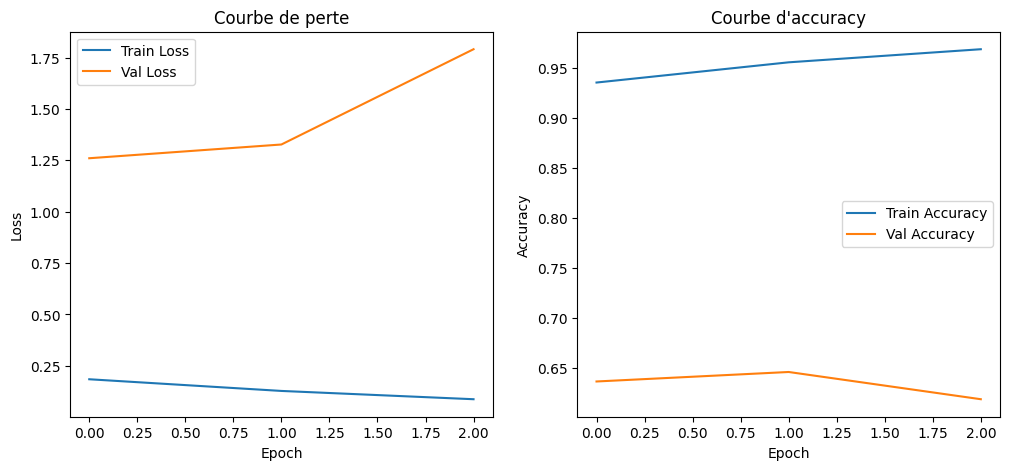

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Courbe de perte")

plt.subplot(1,2,2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Val Accuracy')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Courbe d'accuracy")

plt.show()


In [22]:
from torch.utils.data import TensorDataset, DataLoader

test_dataset = TensorDataset(
    test_inputs,
    test_masks,
    test_token_types
)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


In [23]:
model.eval()
test_preds = []

with torch.no_grad():
    for batch in test_loader:
        input_ids, attention_mask, token_type_ids = [x.to(device) for x in batch]
        outputs = model(input_ids, attention_mask, token_type_ids)
        preds = outputs.argmax(dim=1).cpu().numpy()
        test_preds.extend(preds)


In [24]:
import pandas as pd

submission = pd.DataFrame({
    'id': test_df['id'],
    'label': test_preds
})
submission.to_csv('submission.csv', index=False)
print(submission.head())


           id  label
0  c6d58c3f69      2
1  cefcc82292      1
2  e98005252c      0
3  58518c10ba      1
4  c32b0d16df      2


import numpy as np
from copy import deepcopy

NUM_FOLDS = 5
EPOCHS = 2           # Ajuste selon tes besoins (2 pour test rapide)
BATCH_SIZE = 32      # Ou 16 si manque de mémoire
DROPOUT = 0.3        # Ou 0.5 si surapprentissage

all_val_accuracies = []
all_val_losses = []

for fold, (train_idx, val_idx) in enumerate(folds):
    print(f"\n=== Fold {fold+1}/{NUM_FOLDS} ===")
    # Re-crée les DataLoader pour chaque fold
    train_dataset = TensorDataset(
        train_inputs[train_idx],
        train_masks[train_idx],
        train_token_types[train_idx],
        train_labels[train_idx]
    )
    val_dataset = TensorDataset(
        train_inputs[val_idx],
        train_masks[val_idx],
        train_token_types[val_idx],
        train_labels[val_idx]
    )
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    
    # Réinitialise le modèle et l'optimiseur à chaque fold !
    model = BERTClassifier(dropout=DROPOUT).to(device)
    optimizer = optim.Adam(model.parameters(), lr=2e-5)
    criterion = nn.CrossEntropyLoss()
    
    # Entraînement sur ce fold
    for epoch in range(EPOCHS):
        model.train()
        total_loss, total_correct = 0, 0
        for batch in tqdm(train_loader, desc=f"Fold {fold+1} Epoch {epoch+1}"):
            input_ids, attention_mask, token_type_ids, labels = [x.to(device) for x in batch]
            optimizer.zero_grad()
            outputs = model(input_ids, attention_mask, token_type_ids)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * input_ids.size(0)
            preds = outputs.argmax(dim=1)
            total_correct += (preds == labels).sum().item()
        avg_loss = total_loss / len(train_loader.dataset)
        avg_acc = total_correct / len(train_loader.dataset)
        print(f"  Train Loss: {avg_loss:.4f}, Accuracy: {avg_acc:.4f}")

    # Validation sur ce fold
    model.eval()
    val_loss, val_correct = 0, 0
    with torch.no_grad():
        for batch in val_loader:
            input_ids, attention_mask, token_type_ids, labels = [x.to(device) for x in batch]
            outputs = model(input_ids, attention_mask, token_type_ids)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * input_ids.size(0)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
    avg_val_loss = val_loss / len(val_loader.dataset)
    avg_val_acc = val_correct / len(val_loader.dataset)
    print(f"  Val Loss: {avg_val_loss:.4f}, Val Accuracy: {avg_val_acc:.4f}")

    all_val_losses.append(avg_val_loss)
    all_val_accuracies.append(avg_val_acc)

# Résumé final
print("\n====== Résultat Cross-Validation (5 folds) ======")
print(f"Accuracy moyenne : {np.mean(all_val_accuracies):.4f} (écart-type : {np.std(all_val_accuracies):.4f})")
print(f"Loss moyenne : {np.mean(all_val_losses):.4f} (écart-type : {np.std(all_val_losses):.4f})")
